<a href="https://colab.research.google.com/github/ranaakl/sales_forecasting/blob/main/Project2_Sales_Forecasting_and_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Project Workflow

## Project Overview
- **Objective**: The **Sales Forecasting and Optimization** project aims to predict future sales for a retail or e-commerce
business by using historical sales data. The end goal is to have a model that can
generate accurate sales predictions to help businesses optimize inventory, marketing, and sales strategies.
- **Milestones**: Data Collection, Exploration, Preprocessing, Advanced Analysis, Model Development, Deployment, and Final Documentation.

---

# Team Information

## Team Members
- **Name**: [Rana Elsayed Akl]  
  **Email**: [eng.rana.elsayed@gmail.com]  
  **Role**: [Data Scientist]

- **Name**: [Insert Name]  
  **Email**: [Insert Email]  
  **Role**: [Insert Role]

- **Name**: [Insert Name]  
  **Email**: [Insert Email]  
  **Role**: [Insert Role]

- **Name**: [Insert Name]  
  **Email**: [Insert Email]  
  **Role**: [Insert Role]

- **Name**: [Insert Name]  
  **Email**: [Insert Email]  
  **Role**: [Insert Role]

- **Name**: [Insert Name]  
  **Email**: [Insert Email]  
  **Role**: [Insert Role]

## Additional Information
- **Organization**: [Insert Organization Name]  
- **Project Timeline**: [Insert Start Date - End Date]  
- **Tools Used**: [Insert List of Tools or Frameworks]
- **Contact for Inquiries**: [Insert Email or Point of Contact]

---

# Milestone 1: Data Collection, Exploration, and Preprocessing

## Data Collection
- Acquire a dataset from reliable sources (e.g., Kaggle, UCI Repository, or APIs).
- **Scraping Data**:
  - Increase dataset size through web scraping or APIs (e.g., Selenium, BeautifulSoup).
  - Explore public repositories or other accessible sources for additional data.

In [35]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mehmettahiraslan/customer-shopping-dataset")

print("Path to dataset files:", path)


100%|██████████| 1.63M/1.63M [00:00<00:00, 101MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mehmettahiraslan/customer-shopping-dataset/versions/2


In [36]:
import pandas as pd

df = pd.read_csv(path + "/customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## Dataset Description
- Create a table to explain:
  - **Column Names**
  - **Data Types**
  - **Descriptions**
  - **Potential Use in Analysis**

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


## Data Exploration
- Summary statistics (mean, median, variance).
- Identify missing values, duplicates, and outliers.
- Data distribution visualizations: histograms, box plots, scatter plots.

In [38]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [39]:
from matplotlib import pyplot as plt
import seaborn as sns


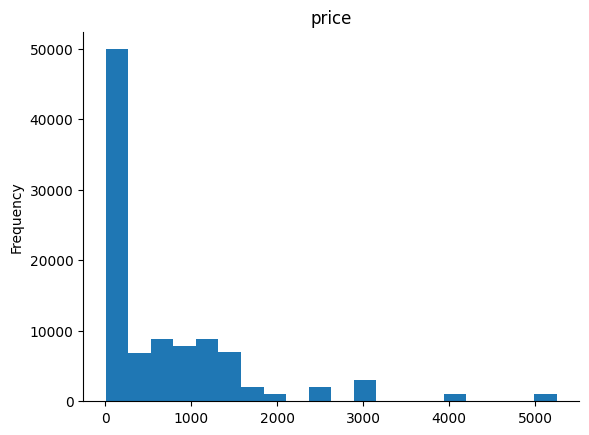

In [41]:
# @title Price

df['price'].plot(kind='hist', bins=20, title='price')
plt.gca().spines[['top', 'right',]].set_visible(False)

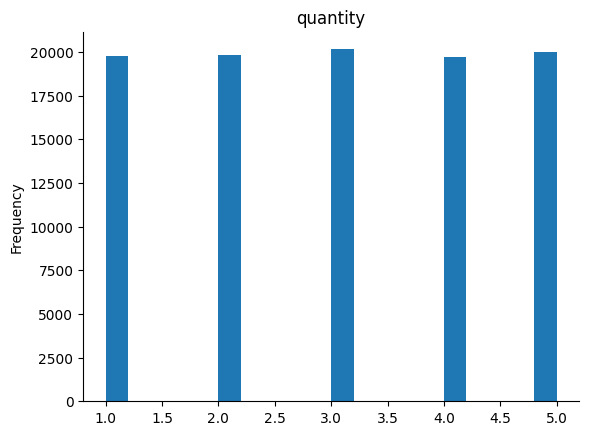

In [42]:
# @title Units_Sold

df['quantity'].plot(kind='hist', bins=20, title='quantity')
plt.gca().spines[['top', 'right',]].set_visible(False)

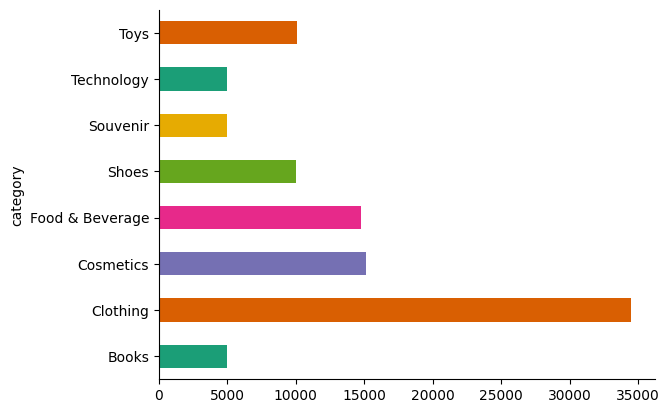

In [43]:
# @title Product_Category

df.groupby('category').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [44]:
df["gender"].value_counts()

,count
gender,
Female,59482
Male,39975


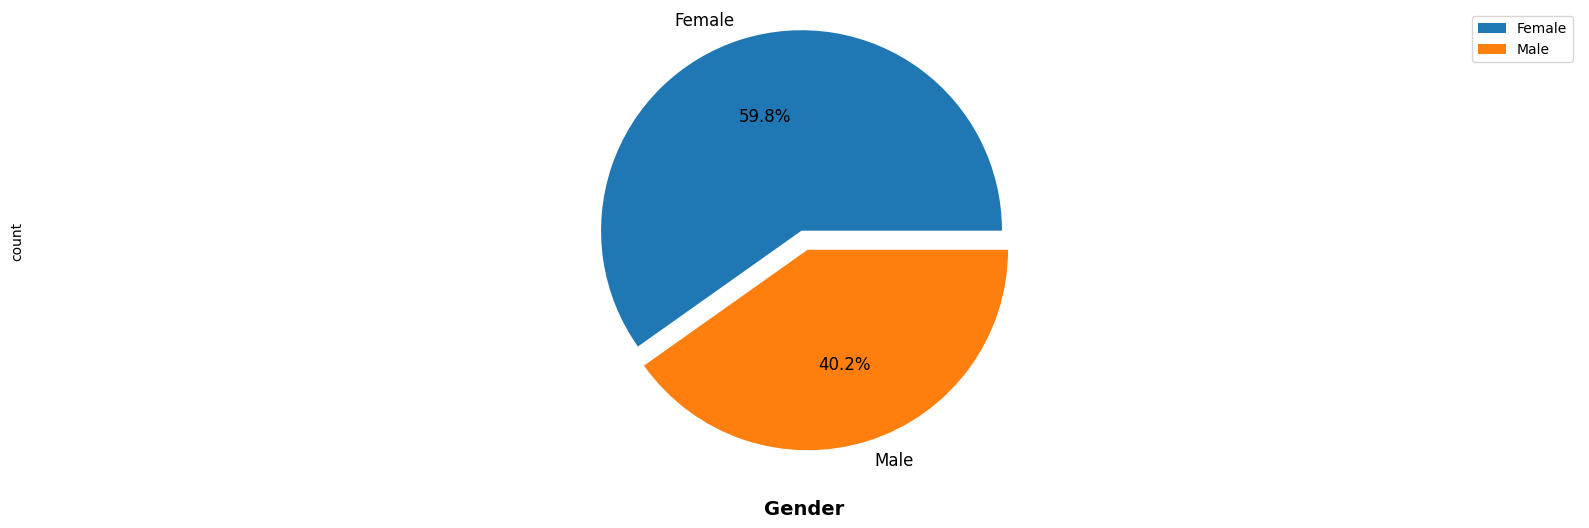

In [61]:
plt.figure(figsize=(20,6))

counts = df["gender"].value_counts()

explode = (0, 0.1)

counts.plot(kind="pie", fontsize=12, color=sns.palettes.mpl_palette('Dark2'), explode=explode, autopct='%1.1f%%')

plt.xlabel("Gender", weight="bold", color="black", fontsize=14, labelpad=20)

plt.legend(labels=counts.index, loc="best")
plt.axis("equal")
plt.show()

In [62]:
df["payment_method"].value_counts()

,count
payment_method,
Cash,44447
Credit Card,34931
Debit Card,20079


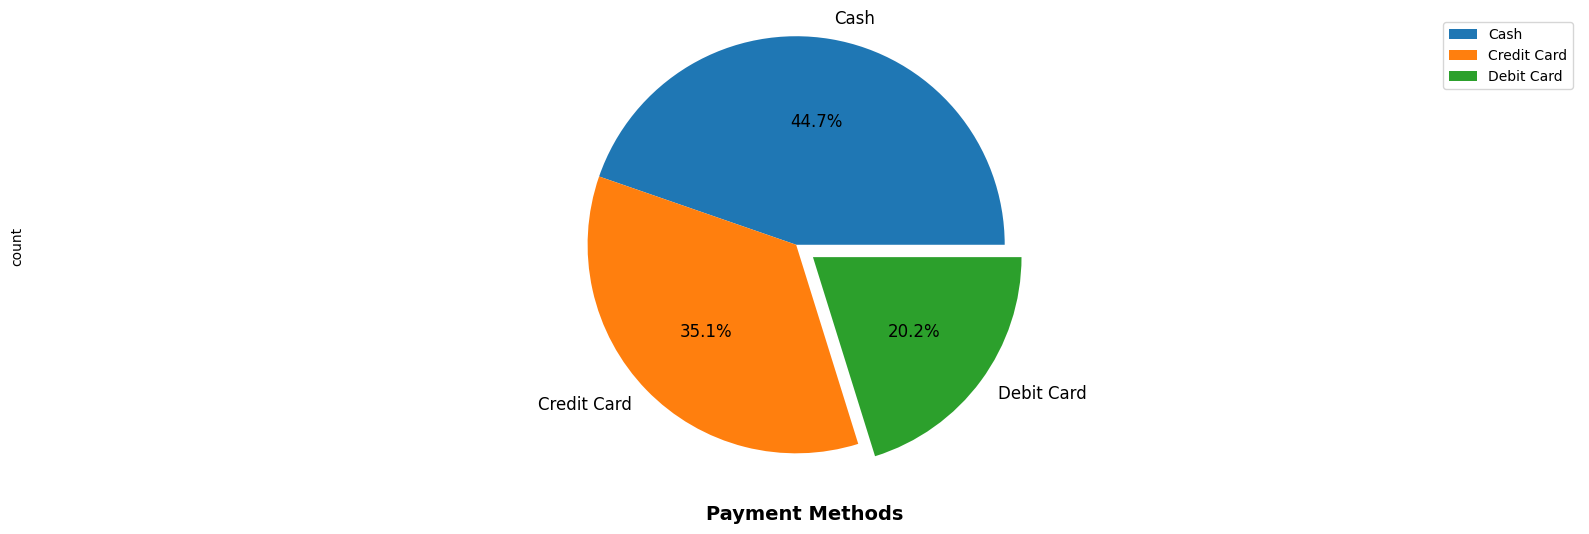

In [64]:
plt.figure(figsize=(20,6))

counts = df["payment_method"].value_counts()

explode = (0, 0, 0.1)

counts.plot(kind="pie", fontsize=12, color=sns.palettes.mpl_palette('Dark2'), explode=explode, autopct='%1.1f%%')

plt.xlabel("Payment Methods", weight="bold", color="black", fontsize=14, labelpad=20)

plt.legend(labels=counts.index, loc="best")
plt.axis("equal")
plt.show()

## Preprocessing and Feature Engineering
- Handle missing values.
- Remove duplicates and outliers.
- Apply transformations (scaling, encoding, feature interactions).


---

# Milestone 2: Advanced Data Analysis and Feature Engineering

## Statistical Analysis
- Conduct tests such as t-tests, ANOVA, and chi-squared to explore relationships.

## Feature Engineering
- Create derived features based on domain knowledge.
- Apply transformations such as normalization, log scaling, or polynomial features.

## Data Visualization
- Generate insightful visualizations:
  - Correlation heatmaps, pair plots.
  - Trends and comparisons using bar charts, line charts, and dashboards.


---


# Milestone 3: Machine Learning Model Development and Optimization

## Model Selection
- Choose appropriate models for the problem type (classification, regression, clustering, etc.).


## Model Training
- Split data into training, validation, and testing sets.
- Address imbalances using techniques like SMOTE or stratified sampling.

## Model Evaluation
- Metrics to consider: Accuracy, Precision, Recall, F1-score, RMSE, etc.
- Visual tools: Confusion matrices, ROC curves.

## Hyperparameter Tuning
- Techniques: Grid Search, Random Search, or advanced methods like Bayesian Optimization.

## Model Comparison
- Compare multiple models and justify the final model selection.


---


# Milestone 4: Deployment and Monitoring

## Deployment
- Deploy the model as a REST API (Flask, FastAPI) or interactive dashboards (Streamlit, Dash).
- Host on cloud platforms (AWS, Azure, GCP) or local servers.

## Monitoring
- Set up performance tracking and alert systems for issues.
- Monitor metrics for potential model drift or anomalies.

## Retraining Strategy
- Plan for periodic retraining with new or updated data.


---


# Milestone 5: Final Documentation and Presentation

## Final Report
- Summarize all project phases, including methodologies and insights.
- Provide actionable recommendations based on findings.

## Final Presentation
- Create a presentation for stakeholders, highlighting key results.
- Include a demo of the deployed application or model.

## Future Improvements
- Suggest areas for enhancement:
  - Incorporating more diverse data.
  - Experimenting with additional algorithms.
  - Optimizing deployment for scalability.

---

# Additional Sections

## Challenges Faced
- Document key challenges encountered during the project lifecycle.

## Lessons Learned
- Reflect on insights and skills gained through the project.

## References
- List resources for datasets, tools, and techniques utilized.

---

# More Sections for Specific Projects

## Ethical Considerations
- Discuss privacy, fairness, or other ethical implications.

## Business Impact
- Highlight how the findings address the original objective.

## Team Contributions
- Acknowledge contributions from team members and collaborators.


---
